# Numbeo Pollution: Data Exploration

Each exploration notebook for a data source should work through the key steps:
1. Loading the data
2. Determining the observation units and the variables of interest
3. Locating and handling missing data
4. Transforming/adding new variables
5. Creating and saving clean subsets
6. Identifying the key dimensions in the dataset (temporal, spatial, categorical)
7. Listing the key questions relating to the overarching research questions
8. Carrying out descriptive analysis of each of the key variables and relevant combinations

## 1. Loading the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px
import math
import plotly

import warnings
warnings.simplefilter('ignore')

import numpy as np
from scipy import stats

def load_numbeo_file(filepath):
    all_years = []
    xl = pd.ExcelFile(filepath)
    for sheet in xl.sheet_names:
        try:
            df = pd.read_excel(filepath, sheet_name=sheet)
            df['year'] = int(str(sheet).strip())
            all_years.append(df)
            print(f'✓ Loaded sheet: {sheet} - {len(df)} rows')
        except Exception as e:
            print(f'✗ Skipped sheet: {sheet} - {e}')
    return pd.concat(all_years, ignore_index=True)

df = load_numbeo_file('../data/raw/numbeo_pollution_country.xlsx')

✓ Loaded sheet: 2016 - 99 rows
✓ Loaded sheet: 2017 - 115 rows
✓ Loaded sheet: 2018 - 98 rows
✓ Loaded sheet: 2019 - 106 rows
✓ Loaded sheet: 2020 - 110 rows
✓ Loaded sheet: 2021 - 112 rows
✓ Loaded sheet: 2022 - 115 rows
✓ Loaded sheet: 2023 - 111 rows
✓ Loaded sheet: 2024 - 112 rows
✓ Loaded sheet: 2025 - 113 rows


In [2]:
print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nYears: {sorted(df["year"].unique())}')
df.head()

Shape: (1091, 5)

Columns: ['Rank', 'Country', 'Pollution Index', 'Exp Pollution Index', 'year']

Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,Rank,Country,Pollution Index,Exp Pollution Index,year
0,1,Egypt,96.0,174.2,2016
1,2,Lebanon,91.9,165.2,2016
2,3,Mongolia,91.0,168.0,2016
3,4,Monaco,90.1,163.5,2016
4,5,Bangladesh,88.3,158.6,2016


## 2. Observation Units and Variables of Interest

The Numbeo country-level pollution dataset is a crowd-sourced ranking of countries, one row per country per year.

**Observation unit:** Country-year

**Variables of interest:**
- `Pollution Index` - 0–100 composite of perceived air, water, noise, and light pollution; cleanliness of streets and satisfaction with green space. **Higher = more polluted.** This sign convention is opposite to the healthcare index and matters for the value-for-living composite - we will invert it downstream.
- `Exp Pollution Index` - exponential rescaling of the base index for display ranking; not an independent measurement and correlates near-perfectly with the base index
- `Rank` - within-year rank assigned by Numbeo (rank 1 = most polluted)

Because this file is already at country level, no City→Country parsing is required and country-level comparisons are directly available.

In [3]:
# Confirm the two index columns are essentially the same information
r, _ = stats.pearsonr(df['Pollution Index'], df['Exp Pollution Index'])
print(f'Correlation between Pollution Index and Exp Pollution Index: r = {r:.3f}')
print('\nFor the rest of this exploration we focus on Pollution Index (the base 0–100 metric).')

Correlation between Pollution Index and Exp Pollution Index: r = 0.999

For the rest of this exploration we focus on Pollution Index (the base 0–100 metric).


## 3. Locating and Handling Missing Data

In [4]:
# Missing values by column
print('Missing values per column:')
print(df.isna().sum().to_string())

# Rows per year - how does country coverage evolve?
print('\nCountry count per year:')
print(df.groupby('year').size().to_string())

Missing values per column:
Rank                   0
Country                0
Pollution Index        0
Exp Pollution Index    0
year                   0

Country count per year:
year
2016     99
2017    115
2018     98
2019    106
2020    110
2021    112
2022    115
2023    111
2024    112
2025    113


In [5]:
# Check whether the same country appears across all years (panel coverage)
country_year_counts = df.groupby('Country')['year'].nunique()
print('Number of years each country appears in:')
print(country_year_counts.value_counts().sort_index().to_string())

n_all_years = (country_year_counts == df['year'].nunique()).sum()
print(f'\nCountries present in ALL {df["year"].nunique()} years: {n_all_years}')

Number of years each country appears in:
year
1      3
2      3
3      1
4      2
5      1
6      1
7      3
8      4
9     13
10    89

Countries present in ALL 10 years: 89


## 4. Transforming and Adding New Variables

In [6]:
# Add a qualitative band on the 0–100 index (higher index = more polluted = worse)
def pollution_band(v):
    if pd.isna(v):   return np.nan
    elif v < 30:     return 'Low'
    elif v < 55:     return 'Moderate'
    elif v < 75:     return 'High'
    else:            return 'Very High'

df['pollution_band'] = df['Pollution Index'].apply(pollution_band)
print(df['pollution_band'].value_counts().to_string())

pollution_band
High         417
Moderate     262
Very High    254
Low          158


## 5. Clean Subsets (in-memory)

In [7]:
# Clean subsets held in memory - no files written, so nothing to sync to GitHub/Colab.
clean_cols = ['year', 'Country', 'Rank',
              'Pollution Index', 'Exp Pollution Index', 'pollution_band']
df_clean = df[clean_cols].sort_values(['year', 'Rank']).reset_index(drop=True)
print(f'Country-year panel: {df_clean.shape[0]} rows')

latest_year = df_clean['year'].max()
df_latest = df_clean[df_clean['year'] == latest_year].copy()
print(f'Latest-year subset ({latest_year}): {df_latest.shape[0]} rows')

Country-year panel: 1091 rows
Latest-year subset (2025): 113 rows


## 6. Key Dimensions in the Dataset

- **Temporal:** 2016 to 2025, annual snapshots
- **Spatial:** country-level, directly usable for country-to-country comparisons
- **Categorical:** pollution band (Low / Moderate / High / Very High) derived from the index
- **Key limitation:** Numbeo pollution is perception-based, not a physical measurement. A country with poor PM2.5 readings that residents are habituated to may score better than a country with mild objective pollution but higher local scrutiny. This diverges from AQI-type measurements and should be read as "perceived environmental quality," not ground truth.

In [8]:
# Year-on-year coverage and overall mean/median
summary = df.groupby('year').agg(
    n_countries=('Country', 'nunique'),
    mean_index=('Pollution Index', 'mean'),
    median_index=('Pollution Index', 'median'),
).round(2)
print(summary.to_string())

      n_countries  mean_index  median_index
year                                       
2016           99       57.91         61.20
2017          115       58.83         63.10
2018           98       57.48         61.90
2019          106       57.27         61.85
2020          110       58.15         62.80
2021          112       57.89         61.50
2022          115       57.98         62.10
2023          111       57.30         61.70
2024          112       57.38         61.55
2025          113       57.08         61.00


## 7. Key Questions Relating to the Research Questions

This notebook is one of the four quality components of the value-for-living index. It feeds most directly into RQ3:

1. **(RQ3)** How wide is the variance in pollution index across countries, and is it comparable in spread to healthcare, crime, and traffic? (variance determines how much this dimension can move overall quality scores)
2. **(RQ3)** Which countries cluster at the dirty vs clean ends of the distribution, and does that align with what we'd expect from per-capita income?
3. **(RQ1/RQ2)** Are low-cost countries systematically dirtier, which would penalize them in the value-for-living composite?
4. **(RQ5)** Has the pollution index trended up or down since 2020, and does the shift survive when restricted to countries that report every year?

## 8. Descriptive Analysis

Pollution Index summary (2025):
count    113.00
mean      57.08
std       20.63
min       11.80
25%       42.00
50%       61.00
75%       73.20
max       93.70


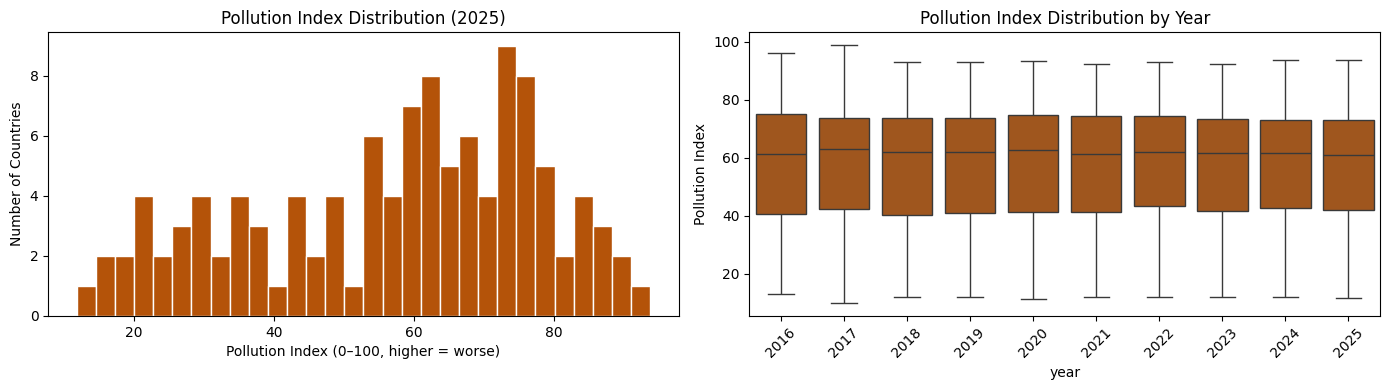

In [9]:
# Distribution of Pollution Index in the latest year
latest = df[df['year'] == df['year'].max()]
print(f'Pollution Index summary ({latest_year}):')
print(latest['Pollution Index'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(latest['Pollution Index'], bins=30, color='#B45309', edgecolor='white')
axes[0].set_title(f'Pollution Index Distribution ({latest_year})')
axes[0].set_xlabel('Pollution Index (0–100, higher = worse)')
axes[0].set_ylabel('Number of Countries')

sns.boxplot(data=df, x='year', y='Pollution Index', ax=axes[1], color='#B45309')
axes[1].set_title('Pollution Index Distribution by Year')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Most polluted and cleanest countries in the latest year
print(f'Most polluted 10 countries ({latest_year}):')
print(latest.nlargest(10, 'Pollution Index')[['Country', 'Pollution Index']].to_string(index=False))

print(f'\nCleanest 10 countries ({latest_year}):')
print(latest.nsmallest(10, 'Pollution Index')[['Country', 'Pollution Index']].to_string(index=False))

Most polluted 10 countries (2025):
    Country  Pollution Index
   Cameroon             93.7
    Myanmar             89.8
    Lebanon             89.4
    Nigeria             87.9
   Mongolia             87.8
      Ghana             86.9
 Bangladesh             85.4
Afghanistan             84.4
    Vietnam             84.2
      Nepal             84.0

Cleanest 10 countries (2025):
    Country  Pollution Index
    Finland             11.8
    Iceland             16.0
    Estonia             17.0
     Sweden             17.6
     Norway             18.3
    Denmark             20.6
    Austria             20.9
Netherlands             21.6
   Slovenia             22.2
Switzerland             23.1


In [11]:
# Full country league table in the latest year (cleanest → most polluted)
country_latest = latest[['Country', 'Pollution Index']].sort_values('Pollution Index')

print(f'Cleanest 15 countries by pollution index ({latest_year}):')
print(country_latest.head(15).round(2).to_string(index=False))

print(f'\nMost polluted 15 countries ({latest_year}):')
print(country_latest.tail(15).round(2).to_string(index=False))

Cleanest 15 countries by pollution index (2025):
    Country  Pollution Index
    Finland             11.8
    Iceland             16.0
    Estonia             17.0
     Sweden             17.6
     Norway             18.3
    Denmark             20.6
    Austria             20.9
Netherlands             21.6
   Slovenia             22.2
Switzerland             23.1
 Luxembourg             23.3
New Zealand             26.1
  Lithuania             26.3
  Australia             26.8
   Portugal             28.8

Most polluted 15 countries (2025):
        Country  Pollution Index
         Monaco             78.2
       Zimbabwe             78.5
North Macedonia             79.6
           Peru             82.4
          Egypt             82.7
          Nepal             84.0
        Vietnam             84.2
    Afghanistan             84.4
     Bangladesh             85.4
          Ghana             86.9
       Mongolia             87.8
        Nigeria             87.9
        Lebanon       

In [12]:
# Trend in mean Pollution Index over time - compare all-countries vs balanced panel
# to separate real movement from sample-change artifacts.
balanced = df.groupby('Country').filter(lambda g: g['year'].nunique() == df['year'].nunique())
print(f'Balanced panel: {balanced["Country"].nunique()} countries across all years')

trend = (
    df.groupby('year')['Pollution Index'].mean().rename('all_countries')
      .to_frame()
      .join(balanced.groupby('year')['Pollution Index'].mean().rename('balanced_panel'))
)
print('\nMean pollution index over time:')
print(trend.round(2).to_string())

fig = px.line(trend.reset_index().melt(id_vars='year', var_name='sample', value_name='mean_index'),
              x='year', y='mean_index', color='sample', markers=True,
              title='Mean Pollution Index Over Time - All Countries vs Balanced Panel',
              labels={'mean_index': 'Mean Pollution Index', 'sample': 'Sample'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

Balanced panel: 89 countries across all years

Mean pollution index over time:
      all_countries  balanced_panel
year                               
2016          57.91           56.93
2017          58.83           56.30
2018          57.48           56.02
2019          57.27           55.71
2020          58.15           55.92
2021          57.89           55.46
2022          57.98           55.28
2023          57.30           55.03
2024          57.38           54.79
2025          57.08           54.54


In [13]:
# Cross-compare pollution with cost of living - are cheap countries systematically dirtier?
col = pd.read_csv('../data/clean/numbeo_cost_of_living_country_clean.csv')
merged = pd.merge(
    df[['Country', 'year', 'Pollution Index']],
    col[['Country', 'year', 'Cost of Living Index']],
    on=['Country', 'year'], how='inner'
)
merged_latest = merged[merged['year'] == latest_year].dropna()
print(f'Countries matched in {latest_year}: {len(merged_latest)}')

r, p = stats.pearsonr(merged_latest['Cost of Living Index'], merged_latest['Pollution Index'])
print(f'Correlation (cost of living vs pollution): r = {r:.3f}, p = {p:.4f}')

fig = px.scatter(merged_latest, x='Cost of Living Index', y='Pollution Index',
                 hover_name='Country', trendline='ols',
                 title=f'Pollution Index vs Cost of Living Index ({latest_year}) - r = {r:.3f}',
                 labels={'Cost of Living Index': 'Cost of Living Index',
                         'Pollution Index': 'Pollution Index (higher = worse)'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

Countries matched in 2025: 111
Correlation (cost of living vs pollution): r = -0.683, p = 0.0000


In [14]:
# Cross-compare with healthcare - do clean countries also have good healthcare?
# This speaks to RQ3: whether quality dimensions move together or independently.
# Load the healthcare country xlsx directly so we don't depend on files written by another notebook.
hc = load_numbeo_file('../data/raw/numbeo_health_care_country.xlsx')
h_merged = pd.merge(
    df[['Country', 'year', 'Pollution Index']],
    hc[['Country', 'year', 'Health Care Index']],
    on=['Country', 'year'], how='inner'
)
h_latest = h_merged[h_merged['year'] == latest_year].dropna()
r, p = stats.pearsonr(h_latest['Pollution Index'], h_latest['Health Care Index'])
print(f'Correlation (pollution vs healthcare) in {latest_year}: r = {r:.3f}, p = {p:.4f}')

fig = px.scatter(h_latest, x='Pollution Index', y='Health Care Index',
                 hover_name='Country', trendline='ols',
                 title=f'Health Care vs Pollution ({latest_year}) - r = {r:.3f}',
                 labels={'Pollution Index': 'Pollution Index (higher = worse)',
                         'Health Care Index': 'Health Care Index'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

✓ Loaded sheet: 2016 - 65 rows
✓ Loaded sheet: 2017 - 80 rows
✓ Loaded sheet: 2018 - 69 rows
✓ Loaded sheet: 2019 - 84 rows
✓ Loaded sheet: 2020 - 93 rows
✓ Loaded sheet: 2021 - 93 rows
✓ Loaded sheet: 2022 - 95 rows
✓ Loaded sheet: 2023 - 94 rows
✓ Loaded sheet: 2024 - 94 rows
✓ Loaded sheet: 2025 - 97 rows
Correlation (pollution vs healthcare) in 2025: r = -0.556, p = 0.0000


In [16]:
# Country-level choropleth using plotly's country-name matching
country_map = latest[['Country', 'Pollution Index']]
fig = px.choropleth(
    country_map,
    locations='Country', locationmode='country names',
    color='Pollution Index', hover_name='Country',
    color_continuous_scale='Oranges',
    title=f'Numbeo Pollution Index by Country ({latest_year})',
    labels={'Pollution Index': 'Pollution Index (higher = worse)'}
)
fig.update_geos(showframe=False, showcoastlines=True, projection_type='natural earth')
fig.update_layout(height=600, margin={'r': 0, 't': 60, 'l': 0, 'b': 0},
                  plot_bgcolor='white', paper_bgcolor='white')
fig